# PSE-823: Advanced Process Dynamics and Control
## Lecture 8 -- Control System Design by Frequency Response
### (Coughanowr & LeBlanc, Ch. 16)

Date: __________

## Agenda

**Part A** -- The Bode stability criterion (Sec. 16.1-16.2)

**Part B** -- Gain and phase margins: designing $K_c$ (Sec. 16.3)

**Part C** -- Ziegler-Nichols settings for the two-tank reactor
(Sec. 16.4)

*Midterm after this lecture.*

### Setup (run once)

- The standard imports, plus a root finder and a queue

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})
from scipy.optimize import brentq
from collections import deque

## Part A
### The Bode Stability Criterion

(Coughanowr & LeBlanc, Ch. 16, Sec. 16.1-16.2)
<!-- source: coughanowr-ch16 -->

### Introduce -- Lecture 7's warning, made quantitative (Fig. 16-1)

- Ex. 15.4's tank ($\tau = 0.203$ min) with the thermocouple 2 ft down
  the pipe ($0.0396$ min dead time), P control, $1/wC = 1/600$.
- Open loop: $G(s) = \dfrac{(K_c/600)\,e^{-0.0396s}}{0.203s + 1}$
  (Eq. 16.1).
- Lecture 7: the lag passes $180^\circ$ near 46 rad/min. **How large
  may $K_c$ be?**

### Derive 1/2 -- the crossover frequency

Phase lag of the open loop equals $180^\circ$:

$$\tan^{-1}(0.203\,\omega_{co}) + 0.0396\,\omega_{co} = \pi$$

Book (read from Fig. 16-2): $\omega_{co} \approx 43$ rad/min,
$AR/(K_c/600) \approx 0.12$.

### Derive 2/2 -- the heuristic loop argument

Open the loop at $\omega_{co}$; a sine goes round once:

If $AR = 1$ the returning wave is $-\sin\omega_{co}t$: close the loop and it
sustains itself. If $AR > 1$ it grows each pass. **Bode criterion:**
unstable if $AR > 1$ where the phase lag is $180^\circ$.
Here $K_{c,u} = 600/0.12 = 5000$.

### Code 1/2 -- solve for the crossover

- Mirrors Derive 1/2: `brentq` finds where the phase equation is zero
- Then $K_{c,u}$ makes $AR = 1$ at that frequency

In [2]:
phase = lambda w: -np.arctan(0.203 * w) - 0.0396 * w     # radians
w_co = brentq(lambda w: phase(w) + np.pi, 1, 100)
A = 1 / np.sqrt(1 + (0.203 * w_co)**2)                   # AR / (Kc/600)
Kcu = 600 / A
print(f"w_co = {w_co:.1f} rad/min, AR/(Kc/600) = {A:.3f}, "
      f"Kc,u = {Kcu:.0f}")

w_co = 42.6 rad/min, AR/(Kc/600) = 0.115, Kc,u = 5220


**Code walkthrough.** `phase` is the open-loop phase in radians: the tank's -atan(0.203 w)
plus the dead time's -0.0396 w (Lecture 7). `brentq(f, a, b)` finds
the root of f between a and b, provided f changes sign there; here
f = phase + pi. Result: w_co = 42.6 rad/min. The AR per unit (Kc/600)
is the tank's 1/sqrt(1 + (0.203 w)^2) = 0.115 (dead time has AR 1),
so Kc,u = 600/0.115 = 5220. The book reads 43 and 0.12 from its graph
and quotes 5000.

### Code 2/2 -- test the criterion by simulation

- Dead time as a **queue**: what goes in comes out `nd` steps later
- Kick the loop, then compare the swing early and late

In [ ]:
def loop(Kc, dt=1e-4, t_end=1.0):
    pipe, T, out = deque([0.0] * round(0.0396 / dt)), 0.0, []
    for k in range(int(t_end / dt)):
        Tm = pipe.popleft()                  # reading, 0.0396 min old
        Q = -Kc * Tm + (6000 if k < 10 else 0)   # P control + kick
        T += dt * (Q / 600 - T) / 0.203      # tank
        pipe.append(T); out.append(T)
    return np.array(out)
for f in [0.9, 1.0, 1.1]:
    y = loop(f * Kcu); n = len(y)
    a, b = np.ptp(y[n//3:2*n//3]), np.ptp(y[2*n//3:])
    print(f"Kc = {f} Kc,u: swing {a:.4f} -> {b:.4f}")

**Code walkthrough.** `deque` is a queue: `popleft` takes the oldest value, `append` adds the
newest. Filled with 396 zeros (0.0396/dt), it hands each tank temperature back
396 steps (0.0396 min) later -- a pure transportation lag. Each step:
read the delayed temperature, compute the P-control heat input (plus a
short initial kick to start the motion), update the tank by Euler.
For 0.9 Kc,u the swing halves, 0.048 -> 0.024 F (stable); at Kc,u it
holds at 0.094 (sustained cycling); at 1.1 Kc,u it grows 0.27 -> 0.45
(unstable). The criterion holds, and the simulation never used it.

### Your Turn (8 min)

**Ex. 16.3.** $G = K_c\,e^{-1.02s}/(s + 1)$.

1. By hand: the crossover equation; check that $\omega_{co} \approx 2$
   rad/min; then $K_{c,u}$.
2. Read the code: what does this print (two decimals)?

```python
print(brentq(lambda w: -np.arctan(w) - 1.02*w + np.pi, 0.5, 5))
```

(1) atan(w) + 1.02 w = pi; at w = 2: 1.107 + 2.04 = 3.147, close.
AR = Kc/sqrt(1 + w^2) = 1 gives Kc,u = sqrt 5 = 2.24.
(2) 2.00 (1.995): the crossover frequency.

### Check -- cold-call

The book warns the Bode criterion is "not quite general" (Fig. 16-4).
What kind of phase curve breaks it?

One that crosses -180 deg more than once (phase curves that are not
monotonic, e.g. with resonant elements or right-half-plane features).
Then the general Nyquist criterion is needed. Most process loops have
AR and phase decreasing steadily with frequency, so Bode suffices.

## Part B
### Gain and Phase Margins

(Coughanowr & LeBlanc, Ch. 16, Sec. 16.3)
<!-- source: coughanowr-ch16 -->

### Introduce -- stable is not enough (Fig. 16-6)

- Time constants are estimates and drift (fouling, wear).
- **Gain margin** $GM = 1/AR|_{\phi = -180^\circ}$: typical
  spec $> 1.7$.
- **Phase margin** $PM = 180^\circ - \phi_{lag}|_{AR = 1}$: typical
  spec $> 30^\circ$.
- Design: satisfy both; take the smaller $K_c$.

### Derive 1/2 -- Ex. 16.1: phase margin and damping

P control, $G = K_c/(s+1)^2$ (tank and sensor, $\tau = \tau_m = 1$):

Gain crossover: $K_c = 1 + \omega^2$; there $PM = 180^\circ -
2\tan^{-1}\omega$. Closed loop (Eq. 12.17): $\zeta_2 =
1/\sqrt{1 + K_c}$. At $\omega = 4$: $K_c = 17$, $PM = 28^\circ$,
$\zeta_2 = 0.24$. **Less margin, less damping.**

### Derive 2/2 -- Ex. 16.2: design for PD and for P

Lecture 7's Ex. 15.7 loop with gain $K_c$:

$\phi = \tan^{-1}0.5\omega - 2\tan^{-1}\omega - \tan^{-1}0.1\omega
- 0.1\omega$ (PD; drop the first term for P).

GM 1.7: $K_c = K_{c,u}/1.7$. PM 30: $K_c = 1/AR$ where
$\phi = -150^\circ$. Book: PD 12.3, P 5.14.

### Code 1/3 -- Ex. 16.1, the margin-damping curve (Fig. 16-9)

- Mirrors Derive 1/2 for a range of gain-crossover frequencies

w = 4: 17 28 0.24


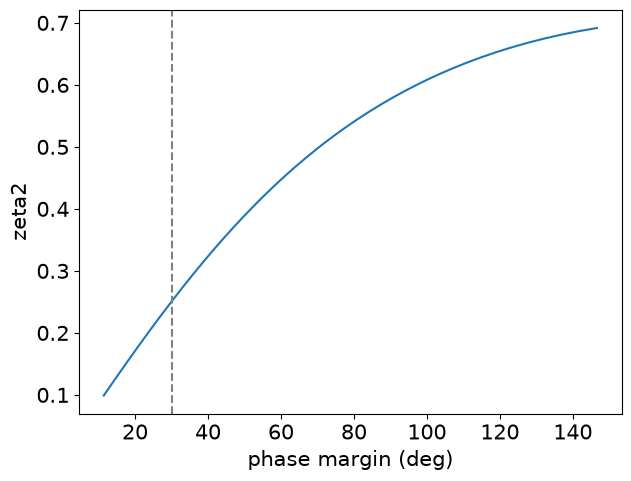

In [4]:
w = np.linspace(0.3, 10, 200)
Kc = 1 + w**2                                  # AR = 1 at w
pm = 180 - 2 * np.degrees(np.arctan(w))
zeta2 = 1 / np.sqrt(1 + Kc)
print("w = 4:", 17, round(180 - 2*np.degrees(np.arctan(4))),
      round(1 / np.sqrt(18), 2))              # Kc, PM, zeta2
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(pm, zeta2); ax.axvline(30, ls="--", c="gray")
ax.set(xlabel="phase margin (deg)", ylabel="zeta2"); plt.show()

**Code walkthrough.** For each candidate gain-crossover frequency w, the gain that puts AR = 1
there is Kc = 1 + w^2 (since |1/(jw + 1)^2| = 1/(1 + w^2)); the phase
margin follows from the phase -2 atan w; the closed-loop damping from
Eq. 12.17. The print checks the book's point at w = 4: Kc = 17,
PM = 28 deg, zeta2 = 0.24. The plot is Fig. 16-9: PM below 30 deg means zeta2 below
about 0.26 -- an oscillatory loop. Margins are a proxy for damping.

### Code 2/3 -- Ex. 16.2: the open loop per unit gain

- Mirrors Derive 2/2: phase as a sum of arctangents, AR as a product
- Written continuously, so no phase unwrapping is needed

In [5]:
def phase(w, pd):                  # radians, Ex. 15.7 without gain
    lead = np.arctan(0.5 * w) if pd else 0
    return lead - 2*np.arctan(w) - np.arctan(0.1*w) - 0.1*w
def ar(w, pd):
    num = np.sqrt(1 + 0.25 * w**2) if pd else 1
    return num / ((1 + w**2) * np.sqrt(1 + 0.01 * w**2))
print(f"{np.degrees(phase(8.62, True)):.1f}, {ar(8.62, True):.4f}")

-180.0, 0.0445


**Code walkthrough.** `phase` adds the four phase contributions of Derive 2/2 (the PD lead
only when `pd` is True); `ar` multiplies the four magnitudes. Neither
includes Kc. The print checks the book's Fig. 16-12 row: at 8.62
rad/min the PD loop has phase -180.0 deg and AR 0.0445 per unit gain.

### Code 3/3 -- Ex. 16.2: $K_c$ from both margins

- Find $\omega$ at $-180^\circ$ and at $-150^\circ$; take the smaller gain

In [6]:
for pd in [True, False]:
    w180 = brentq(lambda w: phase(w, pd) + np.pi, 0.5, 30)
    w150 = brentq(lambda w: phase(w, pd) + np.radians(150), 0.2, 30)
    K_gm, K_pm = 1 / ar(w180, pd) / 1.7, 1 / ar(w150, pd)
    Kc = min(K_gm, K_pm)
    print(f"PD={pd}: GM-> {K_gm:.2f}, PM-> {K_pm:.2f}; "
          f"choose {Kc:.2f}, GM = {1/ar(w180, pd)/Kc:.2f}")

PD=True: GM-> 13.22, PM-> 12.27; choose 12.27, GM = 1.83
PD=False: GM-> 6.68, PM-> 5.14; choose 5.14, GM = 2.21


**Code walkthrough.** For each case `brentq` finds the -180 deg and -150 deg frequencies. The
gain for GM = 1.7 is the ultimate gain 1/AR(w180) divided by 1.7; the
gain for PM = 30 deg makes AR = 1 at -150 deg. The smaller wins.
PD: 13.22 vs 12.27, choose 12.27, GM 1.83. P: 6.68 vs 5.14, choose
5.14, GM 2.21. The book's numbers, to the digit.

### Build on it -- what the extra gain buys

- Offset for a unit load step is $1/(1 + K_c)$ in Fig. 16-10

In [7]:
for name, kc in [("P, Kc = 5.14", 5.14), ("PD, Kc = 12.27", 12.27)]:
    print(f"{name}: offset {100 / (1 + kc):.1f}% of the load change")

P, Kc = 5.14: offset 16.3% of the load change
PD, Kc = 12.27: offset 7.5% of the load change


**Code walkthrough.** With the same loop structure, the steady-state effect of a unit load
change is 1/(1 + Kc). P control with Kc = 5.14 leaves 16.3% of the load
change; PD lets Kc rise to 12.27 at the same margins and leaves 7.5%:
the book's conclusion. Derivative action's phase lead was converted into
gain, and the gain into a smaller offset.

### Your Turn (8 min)

1. By hand: for Ex. 16.2 case 2 (P only), the ultimate gain is 11.35.
   What is the gain margin at the design value $K_c = 5.14$?
2. Read the code: does this print `True` or `False`?

```python
print(1 / ar(brentq(lambda w: phase(w, False) + np.pi, 0.5, 30),
            False) > 10)
```

(1) GM = 11.35/5.14 = 2.21 (above 1.7: the PM spec governed).
(2) True: 1/AR at the -180 deg frequency is the ultimate gain, 11.35 > 10.

### Check -- think-pair-share

In Ex. 16.1 the gain margin is **infinite** for every $K_c$, yet the
book still limits $K_c$ to about 14. Why is a gain margin alone not
enough?

The phase of 1/(s + 1)^2 never reaches -180 deg, so GM is infinite, but
the phase margin shrinks as Kc grows and the closed loop becomes
lightly damped (zeta2 < 0.26 below PM 30 deg). Both margins must be
checked; each catches a different failure.

## Part C
### Ziegler-Nichols Settings

(Coughanowr & LeBlanc, Ch. 16, Sec. 16.4)
<!-- source: coughanowr-ch16 -->

### Introduce -- tuning from two numbers

- Omit the controller; find the crossover $\omega_{co}$ of
  $G_1G_2H$ and its AR, $A$.
- **Ultimate gain** $K_u = 1/A$; **ultimate period**
  $P_u = 2\pi/\omega_{co}$.
- Table 16.1: P $0.5K_u$; PI $0.45K_u$, $\tau_I = P_u/1.2$;
  PID $0.6K_u$, $\tau_I = P_u/2$, $\tau_D = P_u/8$.
- Ex. 16.4: the two-tank reactor of Ch. 10,
  $\dfrac{e^{-0.5s}}{(s+1)(2s+1)}$.

### Derive 1/2 -- the reactor's crossover

Phase of $e^{-0.5s}/[(s+1)(2s+1)]$ equals $-180^\circ$:

$$\tan^{-1}\omega + \tan^{-1}2\omega + 0.5\omega = \pi,\qquad
K_u = \sqrt{(1+\omega^2)(1+4\omega^2)}\Big|_{\omega_{co}}$$

Book (from Fig. 16-16): $\omega_{co} = 1.56$, $K_{1u} = 6.9$,
$P_u = 4.0$ min.

### Derive 2/2 -- why Z-N works

Read Table 16.1 as margins:

P: $0.5K_u$ is a gain margin of 2. PI: integral action adds phase lag,
so a smaller gain ($0.45K_u$) keeps roughly the same margin. PID:
derivative adds lead, so more gain ($0.6K_u$) is tolerated.
**First estimates, not final values.**

### Code 1/3 -- $K_u$, $P_u$ and the Z-N table

- Mirrors Derive 1/2; then apply Table 16.1

In [8]:
ph = lambda w: -np.arctan(w) - np.arctan(2*w) - 0.5*w
w_co = brentq(lambda w: ph(w) + np.pi, 0.5, 5)
Ku = np.sqrt((1 + w_co**2) * (1 + 4 * w_co**2))
Pu = 2 * np.pi / w_co
zn = {"P": (0.5*Ku, None, None), "PI": (0.45*Ku, Pu/1.2, None),
      "PID": (0.6*Ku, Pu/2, Pu/8)}
print(f"w_co = {w_co:.3f}, Ku = {Ku:.2f}, Pu = {Pu:.2f} min")
for k, v in zn.items():
    print(k, [None if x is None else round(float(x), 2) for x in v])

w_co = 1.665, Ku = 6.75, Pu = 3.77 min
P [3.38, None, None]
PI [3.04, 3.14, None]
PID [4.05, 1.89, 0.47]


**Code walkthrough.** The phase equation is solved exactly with `brentq`; Ku is 1/AR there and
Pu the period of the sustained cycle. `zn` is a dictionary holding
(Kc, tau_I, tau_D) for each controller per Table 16.1. Exact values:
w_co = 1.665 rad/min, Ku = 6.75, Pu = 3.77 min -- close to the book's
graph readings 1.56, 6.9, 4.0. Settings: P 3.38; PI 3.04, 3.14 min;
PID 4.05, 1.89 min, 0.47 min (book: 3.5; 3.1; 4.2, 2.0, 0.50).

### Code 2/3 -- margins of the three Z-N loops (Table 16.3)

- Dead time via a 10th-order Pade so `ct.margin` can be used

In [9]:
plant = ct.tf(*ct.pade(0.5, 10)) * ct.tf([1], [2, 3, 1])
def ctrl(Kc, tI=None, tD=None):
    if tI is None: return ct.tf([Kc], [1])
    return Kc * ct.tf([(tD or 0) * tI, tI, 1], [tI, 0])
for k, v in zn.items():
    gm, pm, _, _ = ct.margin(ctrl(*v) * plant)
    print(f"{k}: GM {gm:.2f}, PM {pm:.0f} deg")

P: GM 2.00, PM 39 deg
PI: GM 1.73, PM 25 deg


PID: GM 2.68, PM 35 deg


**Code walkthrough.** A 10th-order Pade approximation (Lecture 4) replaces e^(-0.5s) so the
plant is rational. `ctrl` builds P, or PI/PID as Kc(tD tI s^2 + tI s +
1)/(tI s) (Eq. 16.5); `tD or 0` turns a missing tau_D into 0 for PI.
`ct.margin` returns gain margin, phase margin and the two crossover
frequencies. Expected: P GM 2.0, PM 39; PI 1.73, 25; PID 2.68, 35 --
the book's Table 16.3 pattern (2.0/45, 1.9/33, 2.6/34 from its graph
readings).

### Code 3/3 -- closed-loop set-point responses (Fig. 16-18)

- Unit set-point step; overshoot relative to the final value

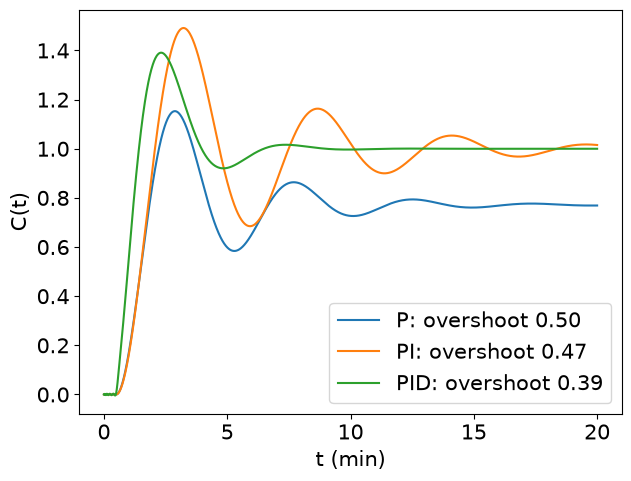

In [10]:
tt = np.linspace(0, 20, 2000)
fig, ax = plt.subplots(figsize=(7, 5.25))
for k, v in zn.items():
    y = ct.step_response(ct.feedback(ctrl(*v) * plant, 1), tt).outputs
    ax.plot(tt, y, label=f"{k}: overshoot {y.max()/y[-1] - 1:.2f}")
ax.set(xlabel="t (min)", ylabel="C(t)"); ax.legend(); plt.show()

**Code walkthrough.** Each controller closes the loop with unity feedback and a unit set-point
step is simulated; the legend reports each overshoot, computed relative
to the value at t = 20 min. Overshoots 0.50, 0.47, 0.39 (book 0.49, 0.46, 0.42);
P settles at 0.77 -- offset 1/(1 + 3.38) -- while PI and PID reach 1.
The PID curve rises fastest and settles in about a third of the time:
derivative action's lead pays off (Fig. 16-18, Table 16.4).

### Your Turn (8 min)

1. By hand: Ex. 16.3 had $K_{c,u} = 2.24$ and $\omega_{co} = 2$
   rad/min. Find the Z-N PI settings.
2. Read the code: with `Ku = 6.75` and `Pu = 3.77`, what does
   `zn["PID"]` hold (two decimals)?

(1) Kc = 0.45(2.24) = 1.01; Pu = 2 pi/2 = 3.14 min; tau_I = 3.14/1.2 =
2.62 min (the book's Ex. 16.3).
(2) (4.05, 1.89, 0.47): 0.6 Ku, Pu/2, Pu/8.

### Check -- poll

The Z-N PID loop overshoots 39%. The plant cannot tolerate more than
25%. Per Fig. 16-19, the first change to try is:

**A)** raise $K_c$  **B)** raise $\tau_I$ (less integral action)
**C)** raise $\tau_D$ only

B (with a slight decrease in Kc). Fig. 16-19: increasing tau_I reduces
overshoot with little loss of speed; tau_D barely changes overshoot;
lowering Kc reduces it but makes the response sluggish. Z-N gives a
starting point; field tuning follows (Lecture 10).

### Wrap-up

**Derived, then coded:** the Bode criterion and the ultimate gain,
checked by a dead-time simulation; gain and phase margins, the
margin-damping link (Ex. 16.1) and margin-based design (Ex. 16.2);
Ziegler-Nichols settings, margins and responses for the two-tank
reactor (Ex. 16.4).

**Tools:** `brentq`, `deque` as a delay, `ct.pade`, `ct.margin`,
`ct.feedback`

**Midterm next.** After it: Ch. 18 -- tuning and process identification.